# Tugas MBC
# Muhammad Abil Khoiri
#101032330094

## 1. Import Libraries and Input Data

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate  # Pastikan Anda menginstal tabulate dengan pip install tabulate

# Memuat dataset pelatihan
df_train = pd.read_csv('train.csv')

# Memuat dataset pengujian
df_test = pd.read_csv('test.csv')

# Memuat contoh file submission
df_sample_submission = pd.read_csv('sample_submission.csv')

# Menampilkan informasi dataset pelatihan dengan format yang lebih baik
print("--- Informasi Dataset Pelatihan (df_train) ---")
print(tabulate(df_train.head(), headers='keys', tablefmt='psql'))  # Menampilkan 5 baris pertama dalam format tabel

print("\n--- Informasi Kolom dan Tipe Data ---")
print(tabulate(df_train.dtypes.reset_index(), headers=['Kolom', 'Tipe Data'], tablefmt='psql'))  # Menampilkan tipe data kolom

print("\n--- Statistik Deskriptif ---")
print(tabulate(df_train.describe(), headers='keys', tablefmt='psql'))  # Menampilkan statistik deskriptif

print("\nShape of df_train:", df_train.shape)


--- Informasi Dataset Pelatihan (df_train) ---
+----+------+---------------+-------------------+-------------------------------+--------------------+----------------+------------------------+----------------------+-----------------+---------------------+--------------------+--------------------------+
|    |   id | blok_gudang   | mode_pengiriman   |   panggilan_layanan_pelanggan |   rating_pelanggan |   harga_produk |   pembelian_sebelumnya | kepentingan_produk   | jenis_kelamin   |   diskon_ditawarkan |   berat_dalam_gram |   pengiriman_tepat_waktu |
|----+------+---------------+-------------------+-------------------------------+--------------------+----------------+------------------------+----------------------+-----------------+---------------------+--------------------+--------------------------|
|  0 |    1 | C             | kapal             |                             3 |                  5 |            180 |                      4 | sedang               | Perempuan       |

## 2. EDA dan Data Preprocessing

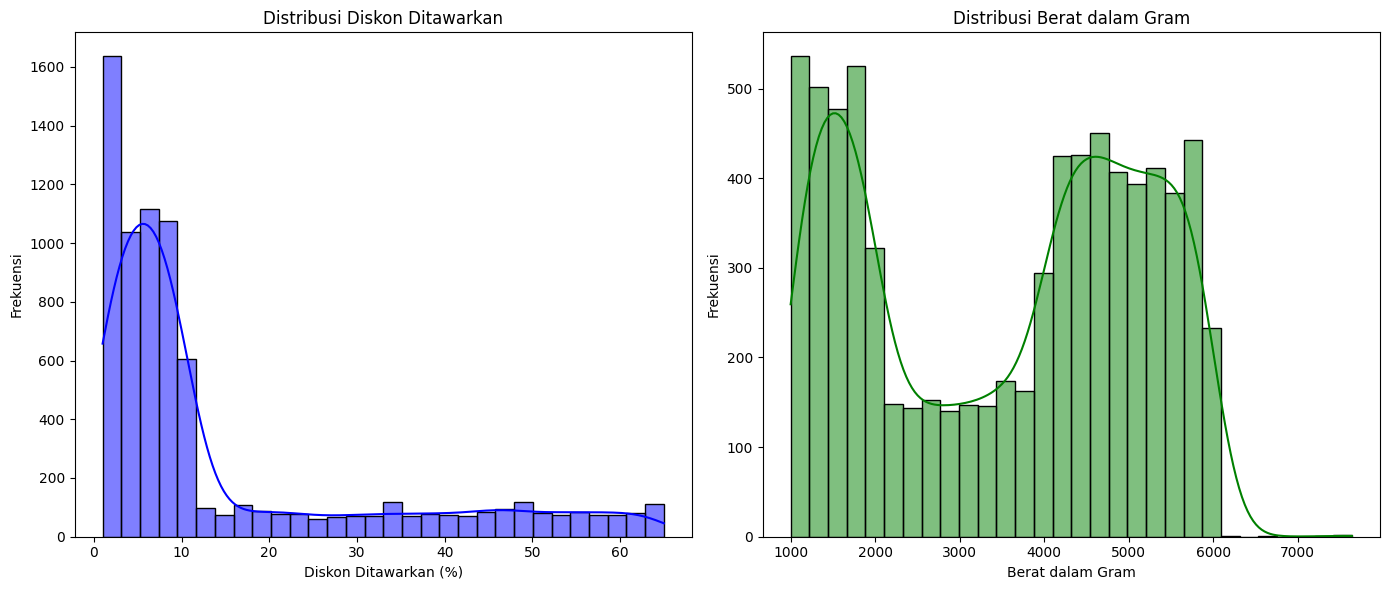

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset pelatihan
df_train = pd.read_csv('train.csv')

# Mengatur ukuran gambar
plt.figure(figsize=(14, 6))

# Histogram untuk diskon_ditawarkan
plt.subplot(1, 2, 1)  # 1 baris, 2 kolom, subplot ke-1
sns.histplot(df_train['diskon_ditawarkan'], bins=30, kde=True, color='blue')
plt.title('Distribusi Diskon Ditawarkan')
plt.xlabel('Diskon Ditawarkan (%)')
plt.ylabel('Frekuensi')

# Histogram untuk berat_dalam_gram
plt.subplot(1, 2, 2)  # 1 baris, 2 kolom, subplot ke-2
sns.histplot(df_train['berat_dalam_gram'], bins=30, kde=True, color='green')
plt.title('Distribusi Berat dalam Gram')
plt.xlabel('Berat dalam Gram')
plt.ylabel('Frekuensi')

# Menampilkan plot
plt.tight_layout()
plt.show()


###Check Missing Value

In [71]:
print("--- df_train.info() ---")
df_train.info()
print("\n--- Missing Values in df_train ---")
print(df_train.isnull().sum() / len(df_train) * 100)

print("\n\n--- df_test.info() ---")
df_test.info()
print("\n--- Missing Values in df_test ---")
print(df_test.isnull().sum() / len(df_test) * 100)

print("\n--- Statistik Deskriptif df_train (Numerik) ---")
print(df_train.describe())

print("\n--- Statistik Deskriptif df_test (Numerik) ---")
print(df_test.describe())






--- df_train.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7551 entries, 0 to 7550
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           7551 non-null   int64  
 1   blok_gudang                  7551 non-null   object 
 2   mode_pengiriman              7551 non-null   object 
 3   panggilan_layanan_pelanggan  7551 non-null   int64  
 4   rating_pelanggan             7551 non-null   int64  
 5   harga_produk                 7484 non-null   float64
 6   pembelian_sebelumnya         7551 non-null   int64  
 7   kepentingan_produk           7445 non-null   object 
 8   jenis_kelamin                7551 non-null   object 
 9   diskon_ditawarkan            7551 non-null   int64  
 10  berat_dalam_gram             7448 non-null   float64
 11  pengiriman_tepat_waktu       7551 non-null   int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 708

###Missing Value Handler

In [73]:
from sklearn.impute import SimpleImputer

# 1. Untuk kolom kategori (kepentingan_produk) - imputasi dengan modus
cat_imputer = SimpleImputer(strategy='most_frequent')
df_train['kepentingan_produk'] = cat_imputer.fit_transform(df_train[['kepentingan_produk']])
df_test['kepentingan_produk'] = cat_imputer.transform(df_test[['kepentingan_produk']])

# 2. Untuk kolom numerik (berat_dalam_gram, harga_produk) - imputasi dengan median
num_imputer = SimpleImputer(strategy='median')
num_cols = ['berat_dalam_gram', 'harga_produk']

df_train[num_cols] = num_imputer.fit_transform(df_train[num_cols])
df_test[num_cols] = num_imputer.transform(df_test[num_cols])

# Verifikasi tidak ada missing values lagi
print("Missing values in train set:", df_train.isnull().sum().sum())
print("Missing values in test set:", df_test.isnull().sum().sum())


Missing values in train set: 0
Missing values in test set: 0


###Visualisasi

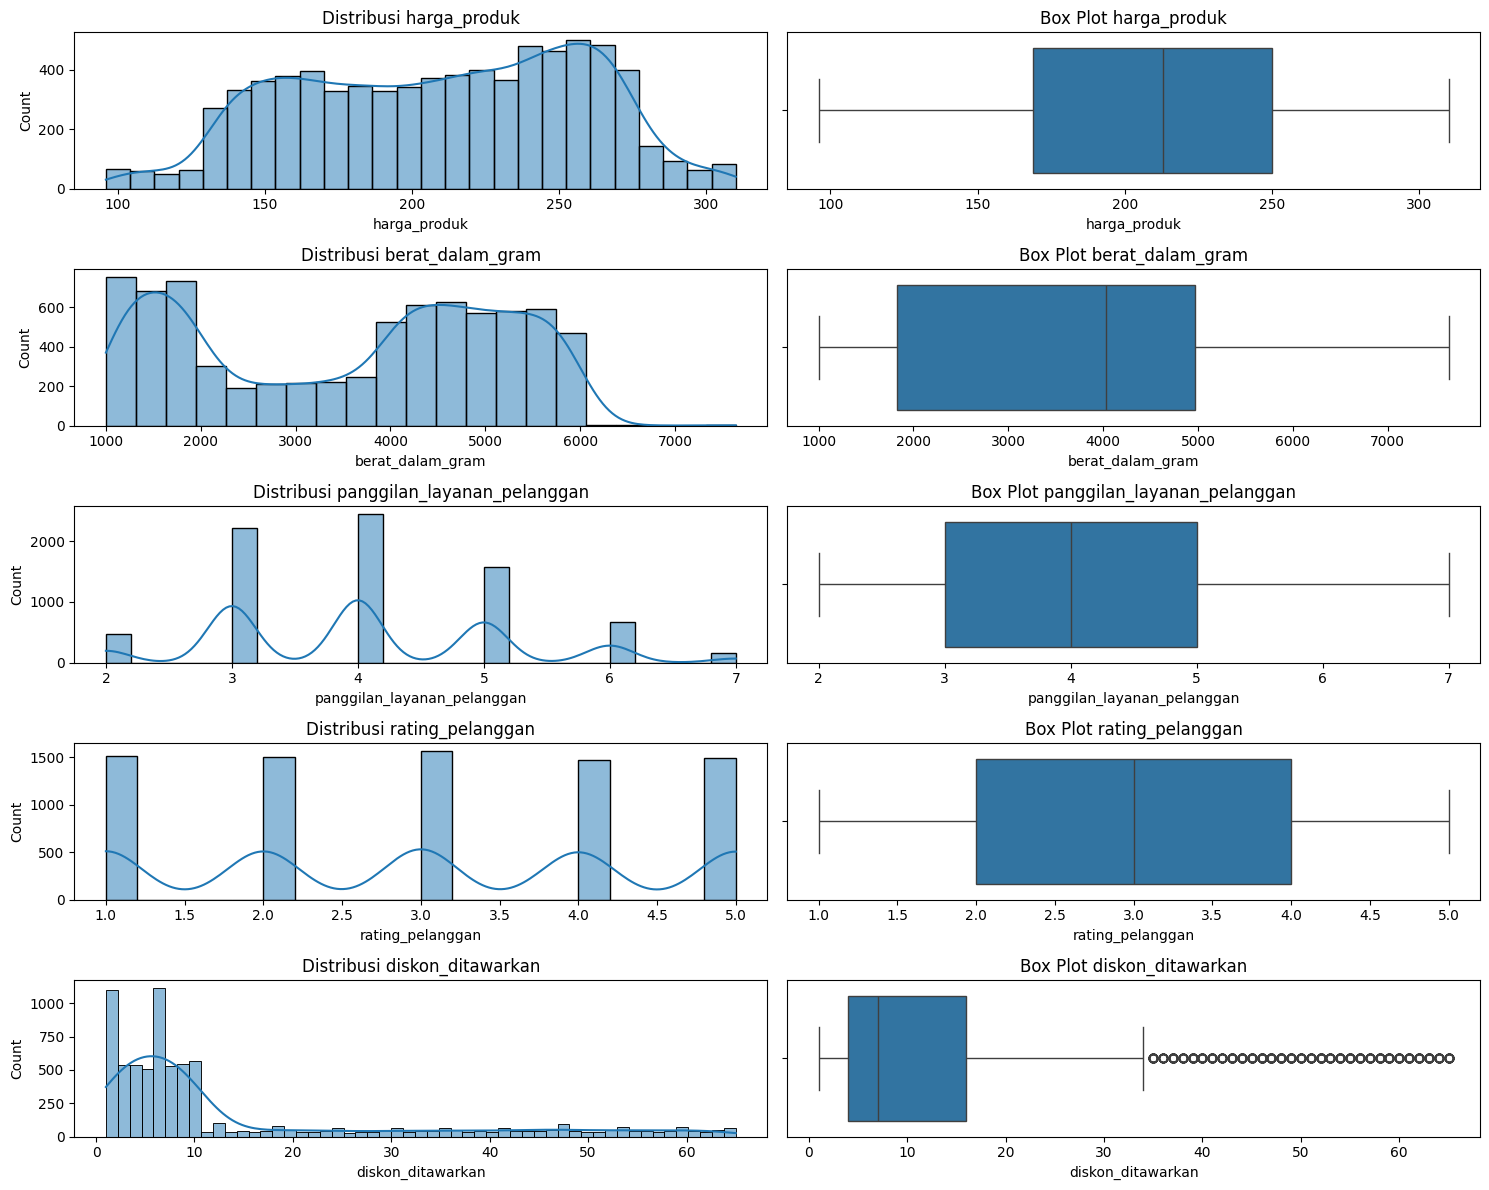

/tmp/ipython-input-36-758706553.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, palette='viridis')
/tmp/ipython-input-36-758706553.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, palette='viridis')
/tmp/ipython-input-36-758706553.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, palette='viridis')
/tmp/ipython-input-36-758706553.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` vari

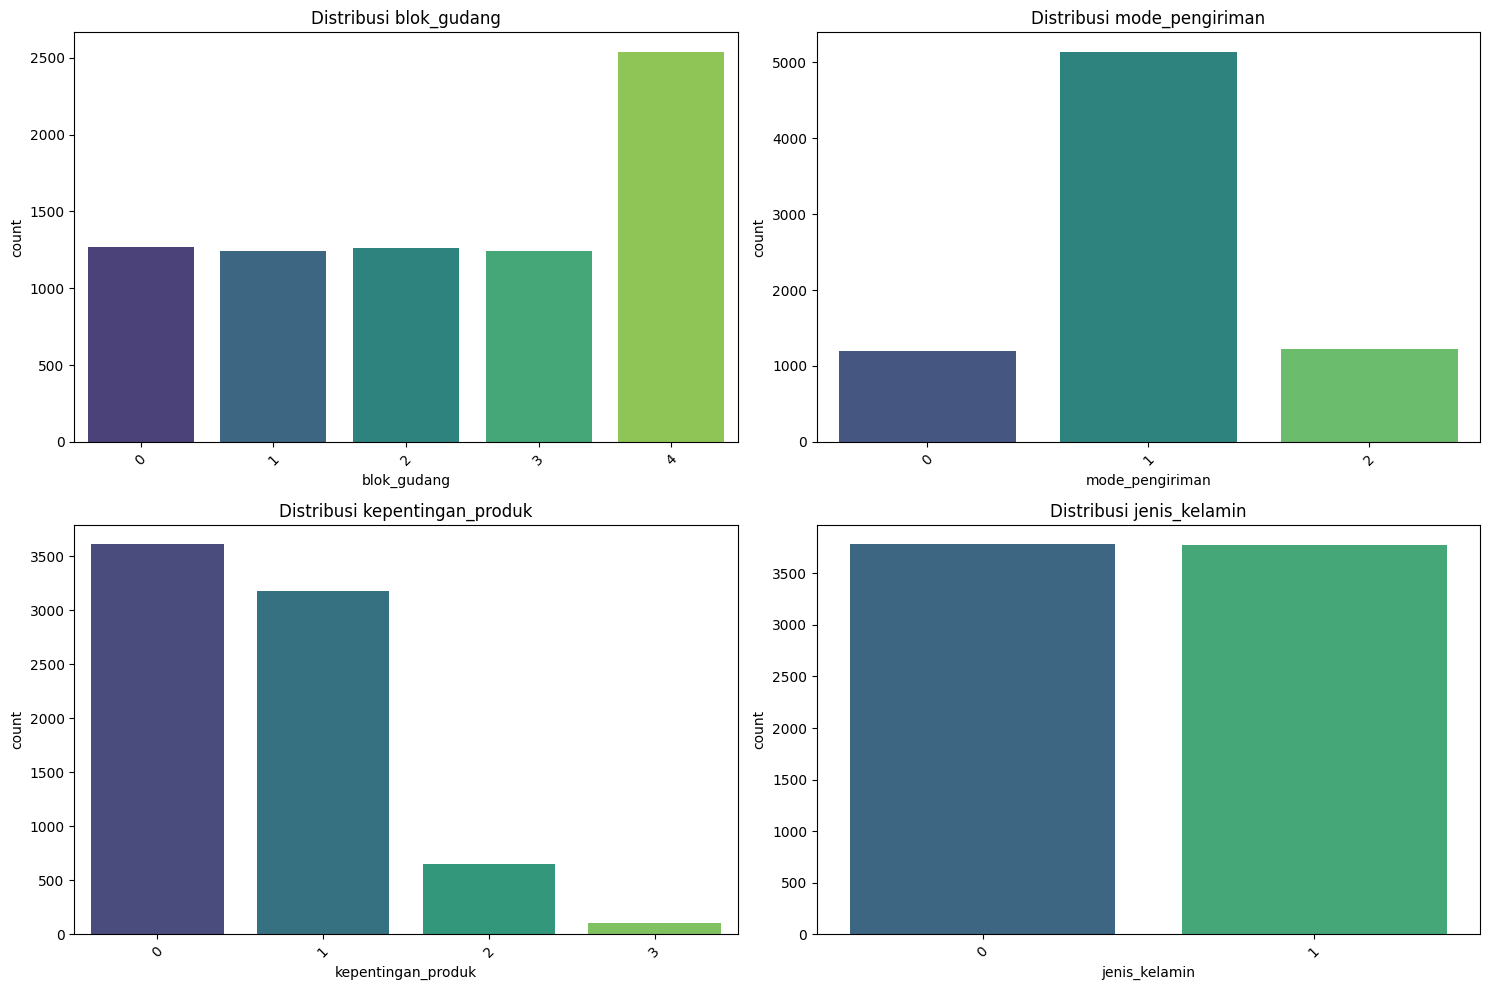

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variabel numerik yang akan dianalisis
numerical_cols = ['harga_produk', 'berat_dalam_gram', 'panggilan_layanan_pelanggan', 'rating_pelanggan', 'diskon_ditawarkan']

# Membuat histogram dan box plot
plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols):
    # Histogram
    plt.subplot(len(numerical_cols), 2, i * 2 + 1)
    sns.histplot(df_train[col], kde=True)
    plt.title(f'Distribusi {col}')

    # Box Plot
    plt.subplot(len(numerical_cols), 2, i * 2 + 2)
    sns.boxplot(x=df_train[col])
    plt.title(f'Box Plot {col}')

plt.tight_layout()
plt.show()

categorical_cols = ['blok_gudang', 'mode_pengiriman', 'kepentingan_produk', 'jenis_kelamin']

plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=df_train, x=col, palette='viridis')
    plt.title(f'Distribusi {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


###Encoding Untuk melihat Matriks Korelasi


--- df_train setelah Label Encoding ---
   id  blok_gudang  mode_pengiriman  panggilan_layanan_pelanggan  \
0   1            2                1                            3   
1   2            2                0                            3   
2   3            4                1                            6   
3   4            4                1                            7   
4   5            0                1                            2   

   rating_pelanggan  harga_produk  pembelian_sebelumnya  kepentingan_produk  \
0                 5         180.0                     4                   1   
1                 4         256.0                     2                   1   
2                 2         293.0                     5                   1   
3                 5         243.0                     5                   1   
4                 5         139.0                     3                   3   

   jenis_kelamin  diskon_ditawarkan  berat_dalam_gram  pengiriman_tepat_wak

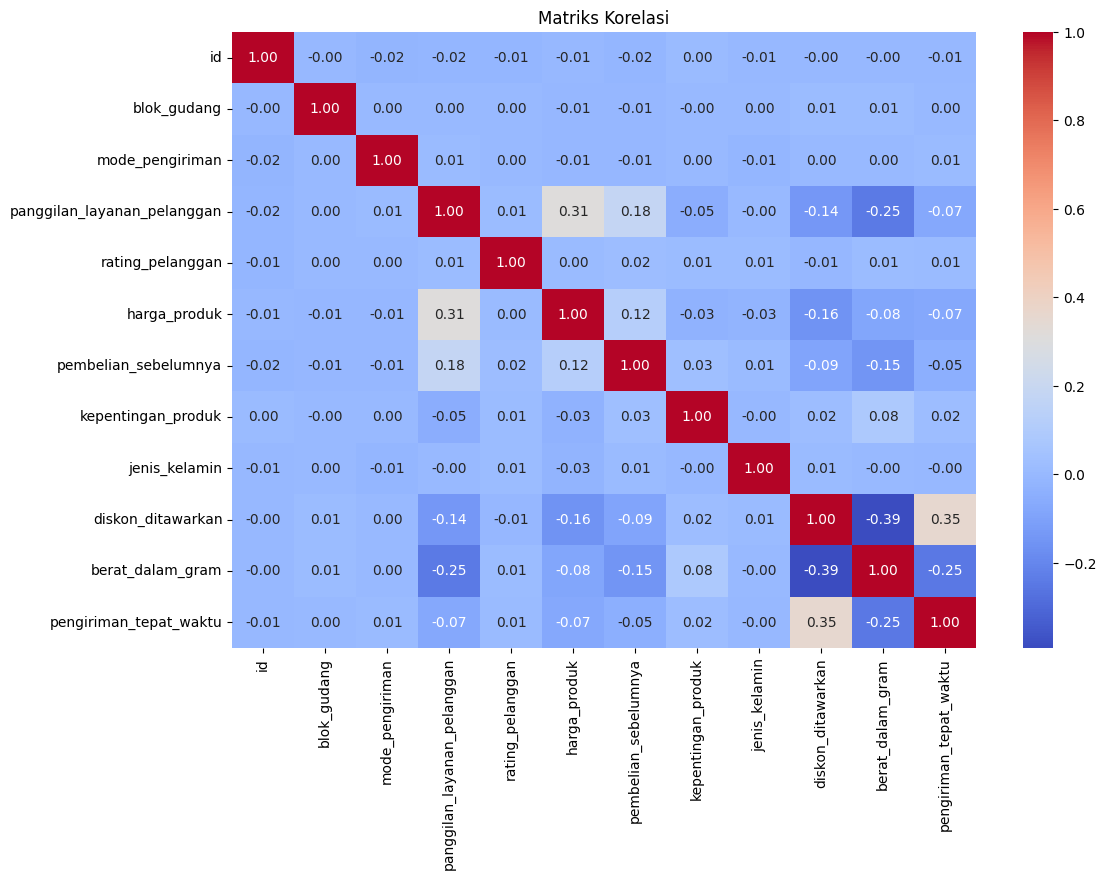

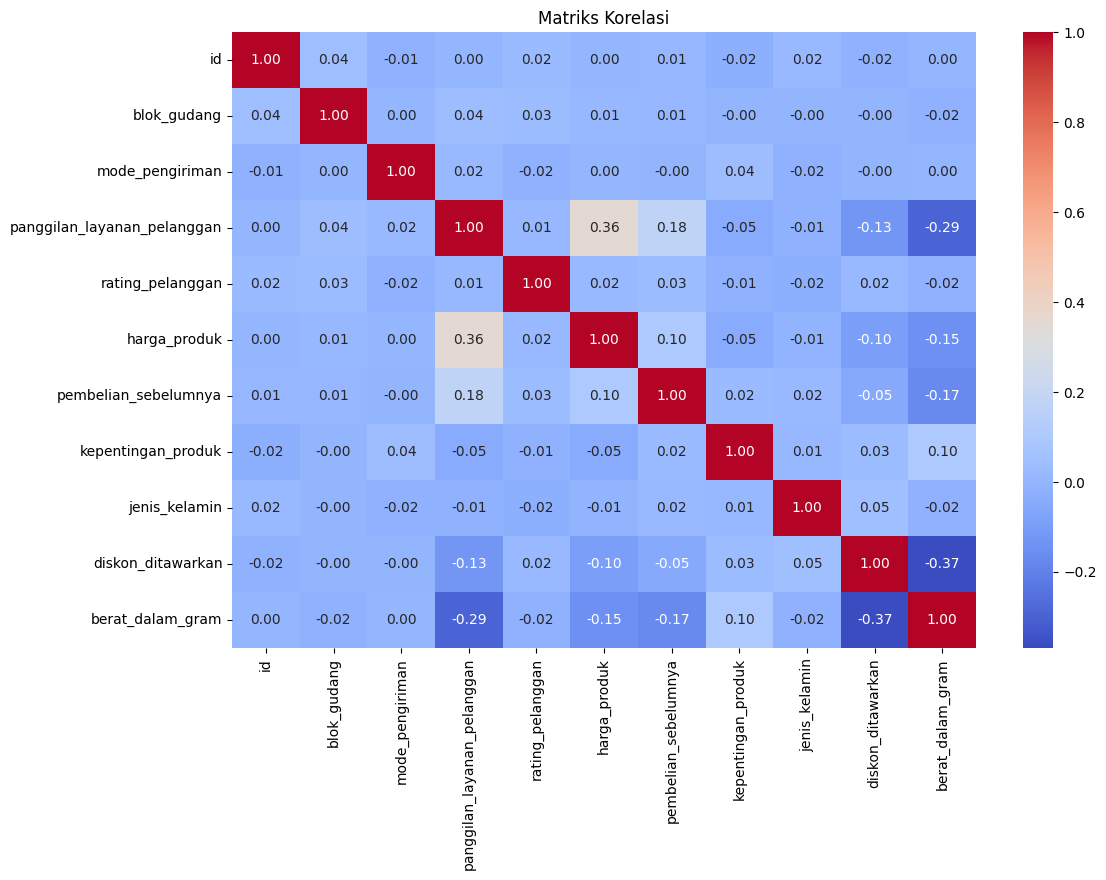

In [72]:
# Inisialisasi LabelEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
# Daftar kolom yang akan di-encode
columns_to_encode = ['jenis_kelamin', 'kepentingan_produk', 'mode_pengiriman', 'blok_gudang']
# Melakukan Label Encoding pada df_train
for col in columns_to_encode:
    df_train[col] = le.fit_transform(df_train[col])
# Melakukan Label Encoding pada df_test
for col in columns_to_encode:
    df_test[col] = le.fit_transform(df_test[col])
print("\n--- df_train setelah Label Encoding ---")
print(df_train.head())
print("\n--- df_test setelah Label Encoding ---")
print(df_test.head())

# Menghitung dan menampilkan matriks korelasi hanya untuk kolom numerik data train
numerical_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df_train[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriks Korelasi')
plt.show()

# Menghitung dan menampilkan matriks korelasi hanya untuk kolom numerik data tes
numerical_cols = df_test.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df_test[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriks Korelasi')
plt.show()




###Menghapus Yang Memiliki Korelasi Yang Rendah Yaitu kolom jenis kelamin, blok gudang


In [74]:
# Daftar kolom yang akan dihapus
# Menambahkan 'id' ke dalam daftar kolom yang akan dihapus
columns_to_drop = ['jenis_kelamin', 'blok_gudang']
# Menghapus kolom dari df_train
df_train = df_train.drop(columns=columns_to_drop)
# Menghapus kolom dari df_test
df_test = df_test.drop(columns=columns_to_drop)
print("\n--- df_train setelah menghapus kolom ---")
print(df_train.head())
print("\nShape of df_train setelah menghapus kolom:", df_train.shape)
print("\n--- df_test setelah menghapus kolom ---")
print(df_test.head())
print("\nShape of df_test setelah menghapus kolom:", df_test.shape)


--- df_train setelah menghapus kolom ---
   id  mode_pengiriman  panggilan_layanan_pelanggan  rating_pelanggan  \
0   1                1                            3                 5   
1   2                0                            3                 4   
2   3                1                            6                 2   
3   4                1                            7                 5   
4   5                1                            2                 5   

   harga_produk  pembelian_sebelumnya  kepentingan_produk  diskon_ditawarkan  \
0         180.0                     4                   1                 59   
1         256.0                     2                   1                 55   
2         293.0                     5                   1                  4   
3         243.0                     5                   1                 28   
4         139.0                     3                   3                 27   

   berat_dalam_gram  pengiriman_tepat_

###Check and Outlier Handling


=== Analisis Outlier Data Train ===


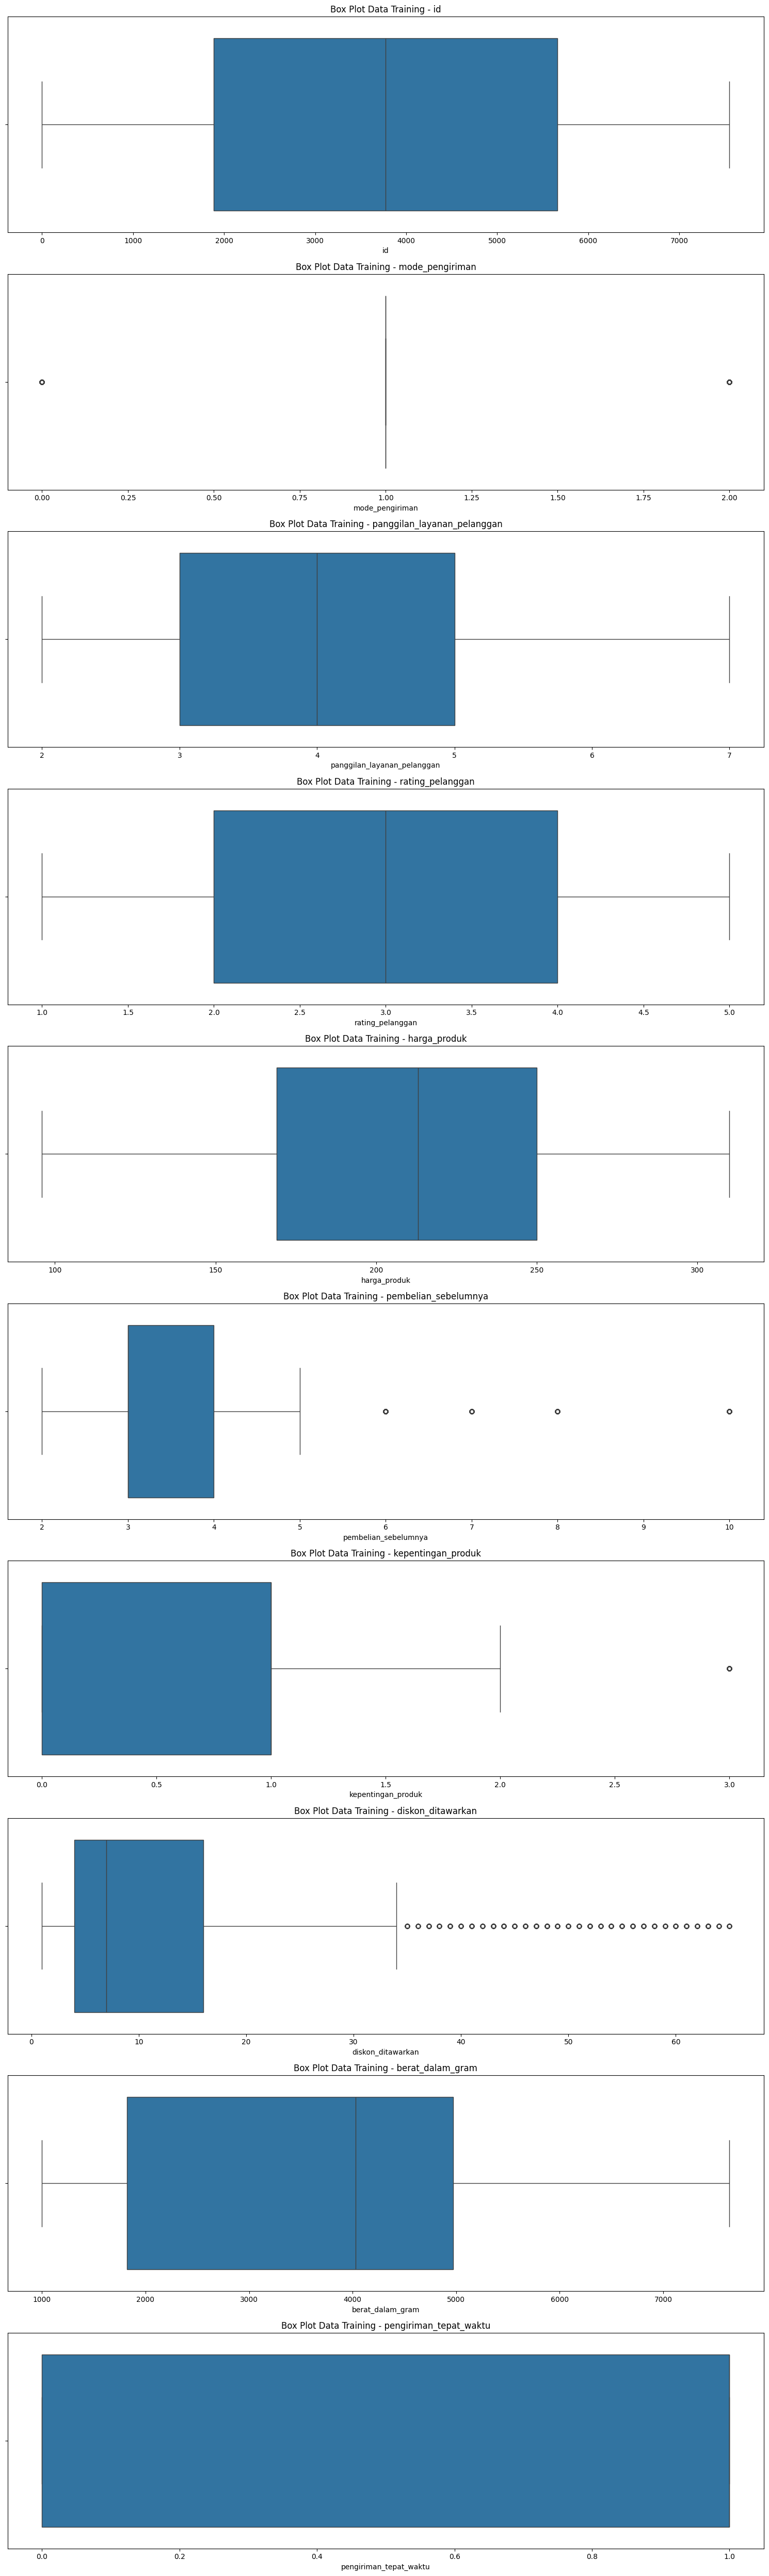


=== Analisis Outlier Data Test ===


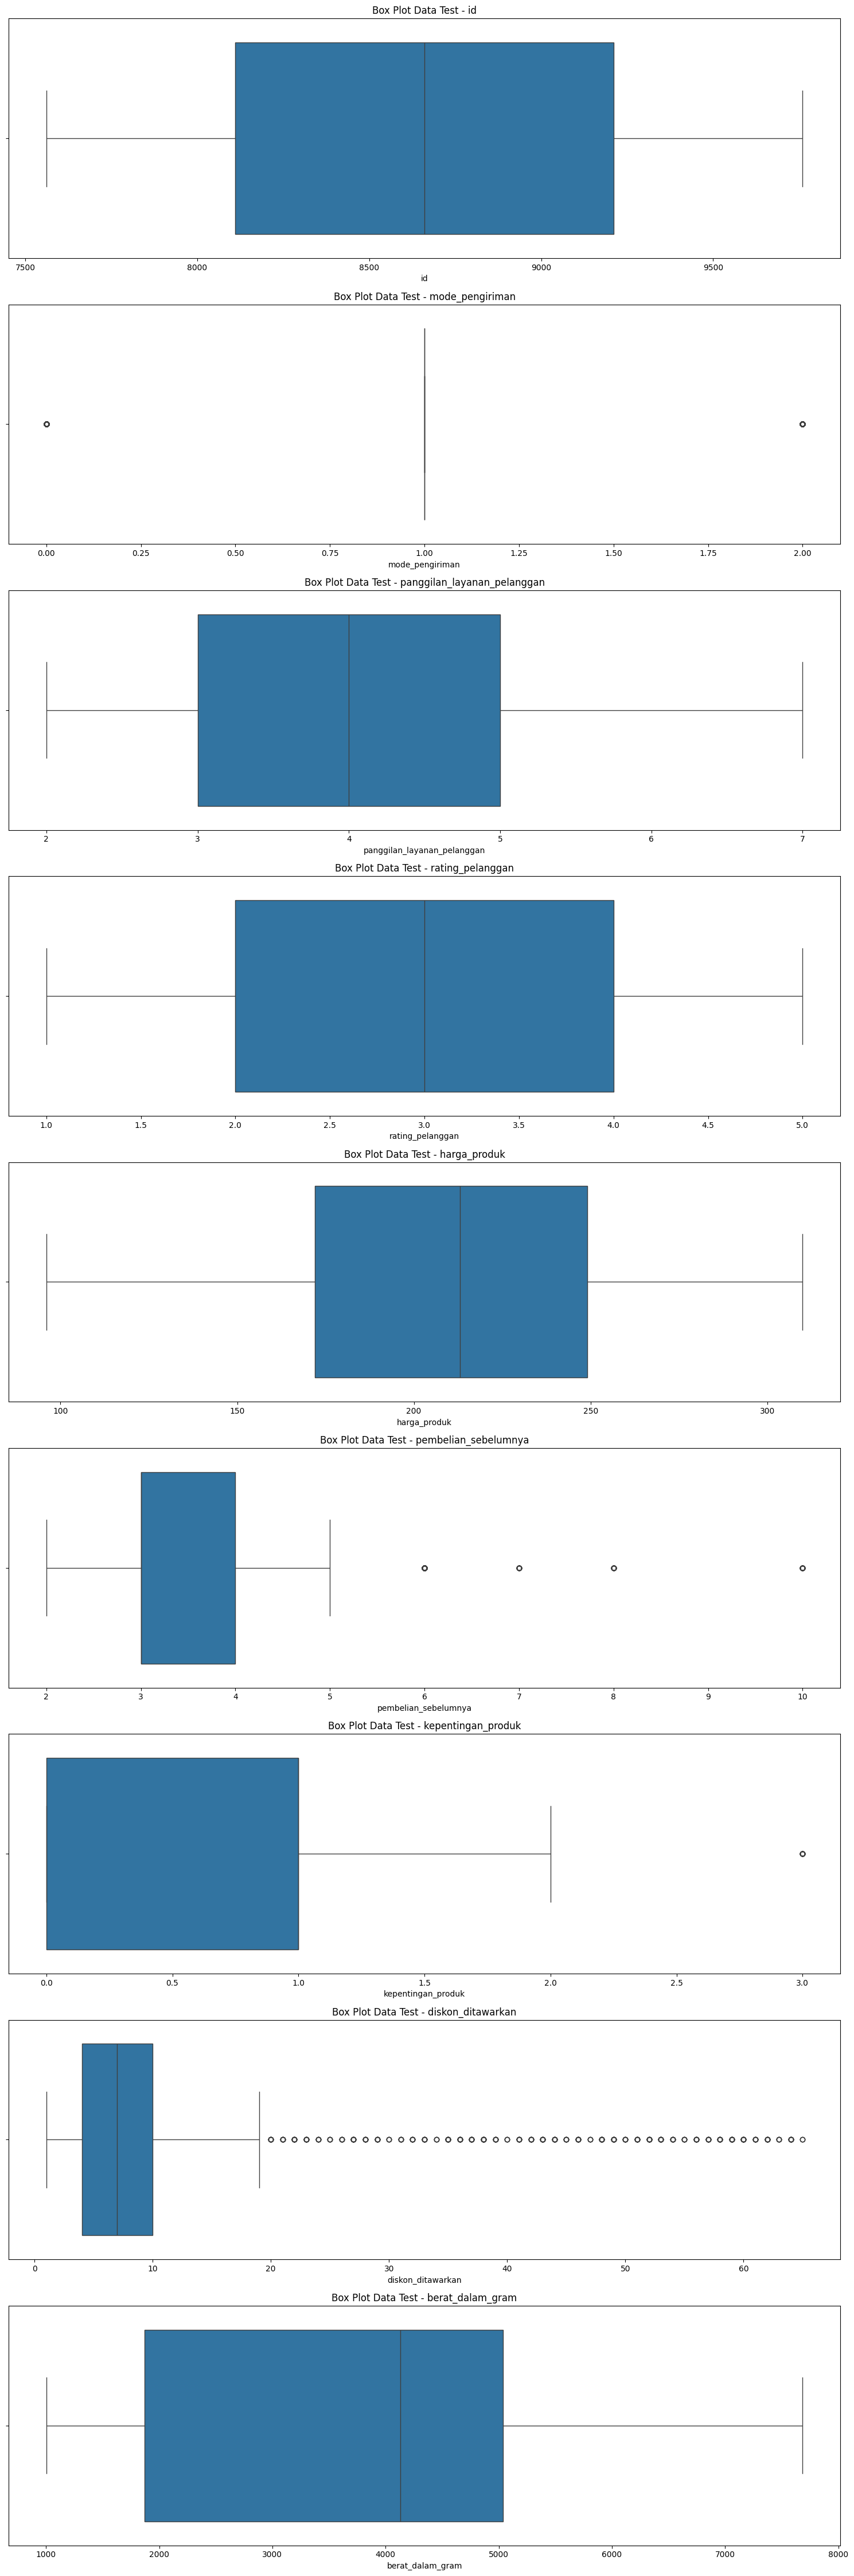

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fungsi untuk membuat box plot analisis outlier
def plot_outliers(df, title):
    # Pilih kolom numerik
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

    # Buat box plot
    plt.figure(figsize=(15, 5*len(numerical_cols)))  # Sesuaikan ukuran berdasarkan jumlah kolom

    for i, col in enumerate(numerical_cols):
        plt.subplot(len(numerical_cols), 1, i+1)
        sns.boxplot(x=df[col])
        plt.title(f'Box Plot {title} - {col}')

    plt.tight_layout()
    plt.show()

# Analisis outlier untuk df_train
print("\n=== Analisis Outlier Data Train ===")
plot_outliers(df_train, "Data Training")

# Analisis outlier untuk df_test
print("\n=== Analisis Outlier Data Test ===")
plot_outliers(df_test, "Data Test")


In [76]:
import numpy as np
import pandas as pd

# --- Outlier Handling ---
# Kolom yang akan di-handle outlier-nya
outlier_cols = ['mode_pengiriman', 'pembelian_sebelumnya', 'diskon_ditawarkan', 'kepentingan_produk']

# Fungsi untuk melakukan capping menggunakan IQR
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

# Lakukan outlier handling untuk df_train
print("\n--- Outlier Handling pada df_train ---")
for col in outlier_cols:
    if col in ['mode_pengiriman', 'pembelian_sebelumnya', 'kepentingan_produk']:
        # Transformasi logaritmik (tambahkan 1 untuk menghindari log(0))
        df_train[col] = np.log1p(df_train[col])
        print(f"  - Kolom '{col}': Transformasi logaritmik dan Capping")
    elif col == 'diskon_ditawarkan':
        print(f"  - Kolom '{col}': Capping")

    # Lakukan capping setelah transformasi (jika ada)
    df_train = cap_outliers_iqr(df_train, col)

# Lakukan outlier handling untuk df_test
print("\n--- Outlier Handling pada df_test ---")
for col in outlier_cols:
    if col in ['mode_pengiriman', 'pembelian_sebelumnya', 'kepentingan_produk']:
        # Transformasi logaritmik (tambahkan 1 untuk menghindari log(0))
        df_test[col] = np.log1p(df_test[col])
        print(f"  - Kolom '{col}': Transformasi logaritmik dan Capping")
    elif col == 'diskon_ditawarkan':
        print(f"  - Kolom '{col}': Capping")

    # Lakukan capping setelah transformasi (jika ada)
    df_test = cap_outliers_iqr(df_test, col)

# Tampilkan hasil setelah outlier handling
print("\n--- df_train setelah Outlier Handling ---")
print(df_train.head())
print("\n--- df_test setelah Outlier Handling ---")
print(df_test.head())



--- Outlier Handling pada df_train ---
  - Kolom 'mode_pengiriman': Transformasi logaritmik dan Capping
  - Kolom 'pembelian_sebelumnya': Transformasi logaritmik dan Capping
  - Kolom 'diskon_ditawarkan': Capping
  - Kolom 'kepentingan_produk': Transformasi logaritmik dan Capping

--- Outlier Handling pada df_test ---
  - Kolom 'mode_pengiriman': Transformasi logaritmik dan Capping
  - Kolom 'pembelian_sebelumnya': Transformasi logaritmik dan Capping
  - Kolom 'diskon_ditawarkan': Capping
  - Kolom 'kepentingan_produk': Transformasi logaritmik dan Capping

--- df_train setelah Outlier Handling ---
   id  mode_pengiriman  panggilan_layanan_pelanggan  rating_pelanggan  \
0   1         0.693147                            3                 5   
1   2         0.693147                            3                 4   
2   3         0.693147                            6                 2   
3   4         0.693147                            7                 5   
4   5         0.693147       

###Scalling

In [77]:
# --- Scaling dengan StandardScaler ---
# Kolom yang akan di-scale
columns_to_scale = ['harga_produk', 'diskon_ditawarkan', 'berat_dalam_gram', 'panggilan_layanan_pelanggan', 'rating_pelanggan']
# Inisialisasi StandardScaler
scaler = StandardScaler()
# Melakukan scaling pada df_train
df_train[columns_to_scale] = scaler.fit_transform(df_train[columns_to_scale])
# Melakukan scaling pada df_test
df_test[columns_to_scale] = scaler.transform(df_test[columns_to_scale])
print("\n--- df_train setelah Scaling ---")
print(df_train.head())
print("\n--- df_test setelah Scaling ---")
print(df_test.head())


--- df_train setelah Scaling ---
   id  mode_pengiriman  panggilan_layanan_pelanggan  rating_pelanggan  \
0   1         0.693147                    -0.907916          1.423633   
1   2         0.693147                    -0.907916          0.714072   
2   3         0.693147                     1.732266         -0.705051   
3   4         0.693147                     2.612326          1.423633   
4   5         0.693147                    -1.787976          1.423633   

   harga_produk  pembelian_sebelumnya  kepentingan_produk  diskon_ditawarkan  \
0     -0.611984              1.609438            0.693147           1.908810   
1      0.970547              1.098612            0.693147           1.908810   
2      1.740989              1.791759            0.693147          -0.702649   
3      0.699850              1.791759            0.693147           1.386518   
4     -1.465718              1.386294            1.386294           1.299469   

   berat_dalam_gram  pengiriman_tepat_waktu  


## 3. Feature Engineering and Selection

###Pembuatan Fitur

In [78]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Assuming df_train and df_test are already defined and cleaned

# --- Feature Engineering ---
# 1. harga_setelah_diskon
df_train['harga_setelah_diskon'] = df_train['harga_produk'] * (1 - df_train['diskon_ditawarkan'] / 100)
df_test['harga_setelah_diskon'] = df_test['harga_produk'] * (1 - df_test['diskon_ditawarkan'] / 100)

# 2. berat_per_diskon
df_train['berat_per_diskon'] = df_train['berat_dalam_gram'] / (df_train['diskon_ditawarkan'] + 1)
df_test['berat_per_diskon'] = df_test['berat_dalam_gram'] / (df_test['diskon_ditawarkan'] + 1)

# 3. produk_ringan
df_train['produk_ringan'] = (df_train['berat_dalam_gram'] < 1000).astype(int)
df_test['produk_ringan'] = (df_test['berat_dalam_gram'] < 1000).astype(int)

# 4. diskon_tinggi
df_train['diskon_tinggi'] = (df_train['diskon_ditawarkan'] > 50).astype(int)
df_test['diskon_tinggi'] = (df_test['diskon_ditawarkan'] > 50).astype(int)

# 5. skor_pelanggan
df_train['skor_pelanggan'] = df_train['rating_pelanggan'] - df_train['panggilan_layanan_pelanggan']
df_test['skor_pelanggan'] = df_test['rating_pelanggan'] - df_test['panggilan_layanan_pelanggan']

# 6. high_value_order
df_train['high_value_order'] = ((df_train['harga_produk'] > 10000) & (df_train['kepentingan_produk'] == 'Tinggi')).astype(int)
df_test['high_value_order'] = ((df_test['harga_produk'] > 10000) & (df_test['kepentingan_produk'] == 'Tinggi')).astype(int)

# 7. is_frequent_buyer
df_train['is_frequent_buyer'] = (df_train['pembelian_sebelumnya'] > 5).astype(int)
df_test['is_frequent_buyer'] = (df_test['pembelian_sebelumnya'] > 5).astype(int)

# 8. produk_penting_dan_ringan
df_train['produk_penting_dan_ringan'] = ((df_train['kepentingan_produk'] == 'Tinggi') & (df_train['berat_dalam_gram'] < 1000)).astype(int)
df_test['produk_penting_dan_ringan'] = ((df_test['kepentingan_produk'] == 'Tinggi') & (df_test['berat_dalam_gram'] < 1000)).astype(int)



# 9. customer_loyalty
df_train['customer_loyalty'] = (0.6 * (df_train['pembelian_sebelumnya'] / df_train['pembelian_sebelumnya'].max()) +
                                 0.4 * (df_train['rating_pelanggan'] / df_train['rating_pelanggan'].max()))
df_test['customer_loyalty'] = (0.6 * (df_test['pembelian_sebelumnya'] / df_test['pembelian_sebelumnya'].max()) +
                                0.4 * (df_test['rating_pelanggan'] / df_test['rating_pelanggan'].max()))

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Fungsi untuk melakukan capping outliers menggunakan IQR
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

# Melakukan capping pada fitur yang diminta
df_train = cap_outliers_iqr(df_train, 'diskon_ditawarkan')
df_test = cap_outliers_iqr(df_test, 'diskon_ditawarkan')

df_train = cap_outliers_iqr(df_train, 'berat_per_diskon')
df_test = cap_outliers_iqr(df_test, 'berat_per_diskon')

df_train = cap_outliers_iqr(df_train, 'skor_pelanggan')
df_test = cap_outliers_iqr(df_test, 'skor_pelanggan')

# Menampilkan DataFrame yang telah diperbarui
print("\n--- Data Frame Train Setelah Capping ---")
print(df_train.head())
print("\nKolom terakhir:", list(df_train.columns)[-3:])
print("\n--- Data Frame Test Setelah Capping ---")
print(df_test.head())
print("\nKolom terakhir:", list(df_test.columns)[-3:])



# Display the updated DataFrames
print("\n--- Data Frame Train ---")
print(df_train.head())
print("\nKolom terakhir:", list(df_train.columns)[-3:])
print("\n--- Data Frame Test ---")
print(df_test.head())
print("\nKolom terakhir:", list(df_test.columns)[-3:])



--- Data Frame Train Setelah Capping ---
   id  mode_pengiriman  panggilan_layanan_pelanggan  rating_pelanggan  \
0   1         0.693147                    -0.907916          1.423633   
1   2         0.693147                    -0.907916          0.714072   
2   3         0.693147                     1.732266         -0.705051   
3   4         0.693147                     2.612326          1.423633   
4   5         0.693147                    -1.787976          1.423633   

   harga_produk  pembelian_sebelumnya  kepentingan_produk  diskon_ditawarkan  \
0     -0.611984              1.609438            0.693147           1.908810   
1      0.970547              1.098612            0.693147           1.908810   
2      1.740989              1.791759            0.693147          -0.702649   
3      0.699850              1.791759            0.693147           1.386518   
4     -1.465718              1.386294            1.386294           1.299469   

   berat_dalam_gram  pengiriman_tepat_

## 4. Data Splitting

###Data Split + Target

In [79]:
from sklearn.model_selection import train_test_split
# Separate features and target
X = df_train.drop(columns=['pengiriman_tepat_waktu'])
y = df_train['pengiriman_tepat_waktu']
# Split train data (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# Test set (features only)
X_test = df_test  # No target column in test data

## 5. Modelling and Evaluation

###Random Forest

Random Forest Model Metrics:
Accuracy: 0.6578424884182661
Precision: 0.7293497363796133
Recall: 0.7988450433108758
F1 Score: 0.7625172255397336
AUC Score: 0.7145519648945368


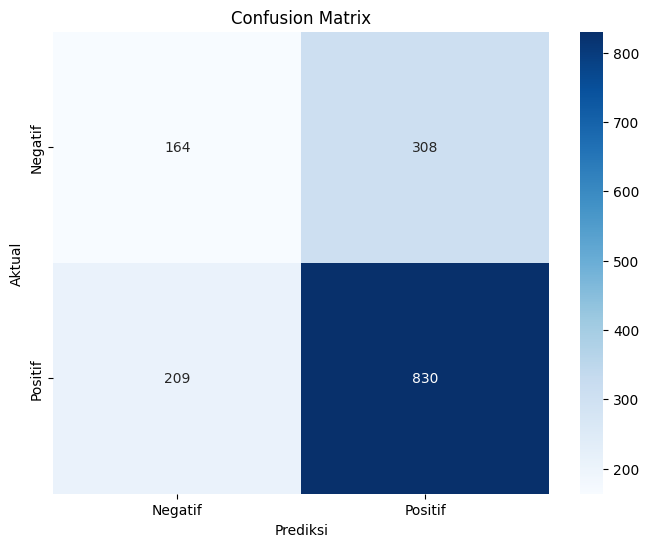

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
# Assuming X and y are your features and labels
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
val_preds = rf_model.predict(X_val)
val_probs = rf_model.predict_proba(X_val)[:, 1]  # Get probabilities for the positive class

# Calculate metrics
accuracy = accuracy_score(y_val, val_preds)
precision = precision_score(y_val, val_preds)
recall = recall_score(y_val, val_preds)
f1 = f1_score(y_val, val_preds)
auc_score = roc_auc_score(y_val, val_probs)

# Print the results
print("Random Forest Model Metrics:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("AUC Score:", auc_score)

# Calculate confusion matrix
cm = confusion_matrix(y_val, val_preds)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


###XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:41:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Model Metrics:
Accuracy: 0.6671078755790867
Precision: 0.7380106571936057
Recall: 0.7998075072184793
F1 Score: 0.7676674364896073
AUC Score: 0.726648015529926


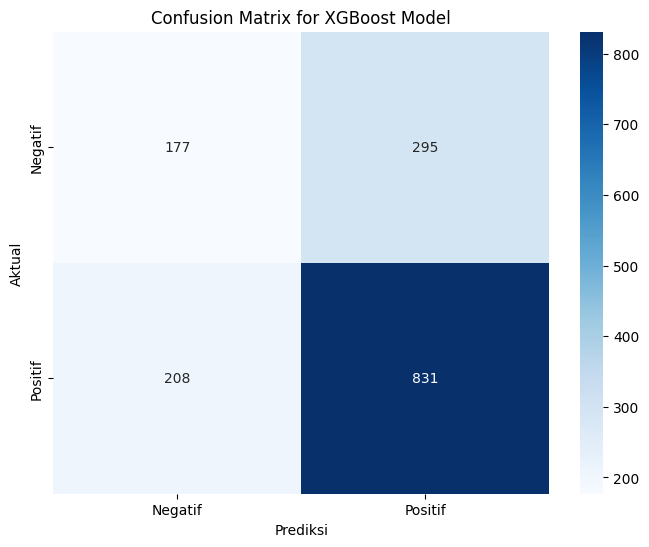

In [82]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
val_preds_xgb = xgb_model.predict(X_val)
val_probs_xgb = xgb_model.predict_proba(X_val)[:, 1]  # Get probabilities for the positive class

# Calculate metrics
accuracy_xgb = accuracy_score(y_val, val_preds_xgb)
precision_xgb = precision_score(y_val, val_preds_xgb)
recall_xgb = recall_score(y_val, val_preds_xgb)
f1_xgb = f1_score(y_val, val_preds_xgb)
auc_score_xgb = roc_auc_score(y_val, val_probs_xgb)

# Print the results
print("XGBoost Model Metrics:")
print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1 Score:", f1_xgb)
print("AUC Score:", auc_score_xgb)

# Calculate confusion matrix
cm_xgb = confusion_matrix(y_val, val_preds_xgb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix for XGBoost Model')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


###Gradient Boosting

Gradient Boosting Model Metrics:
Accuracy: 0.6677696889477167
Precision: 0.701123595505618
Recall: 0.9008662175168431
F1 Score: 0.7885425442291492
AUC Score: 0.727065015252606


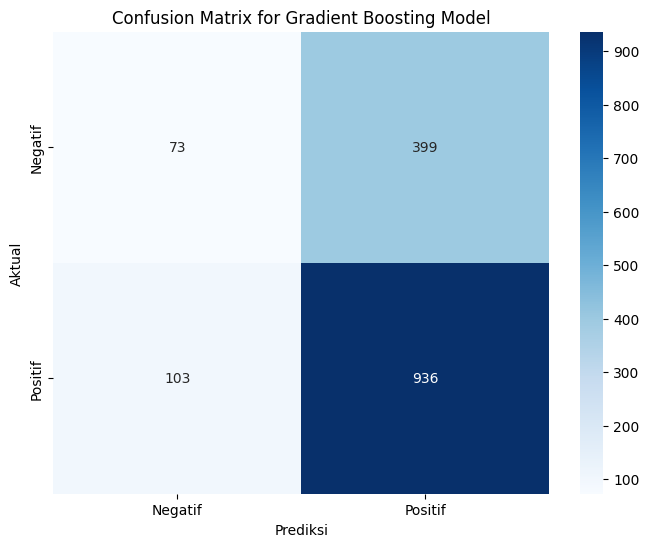

In [87]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pipeline with imputer and model
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # You can change strategy as needed
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Fit the model
pipeline.fit(X_train, y_train)

# Make predictions
val_preds_gb = pipeline.predict(X_val)
val_probs_gb = pipeline.predict_proba(X_val)[:, 1]  # Get probabilities for the positive class

# Calculate metrics
accuracy_gb = accuracy_score(y_val, val_preds_gb)
precision_gb = precision_score(y_val, val_preds_gb)
recall_gb = recall_score(y_val, val_preds_gb)
f1_gb = f1_score(y_val, val_preds_gb)
auc_score_gb = roc_auc_score(y_val, val_probs_gb)

# Print the results
print("Gradient Boosting Model Metrics:")
print("Accuracy:", accuracy_gb)
print("Precision:", precision_gb)
print("Recall:", recall_gb)
print("F1 Score:", f1_gb)
print("AUC Score:", auc_score_gb)

# Calculate confusion matrix
cm_gb = confusion_matrix(y_val, val_preds_gb)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix for Gradient Boosting Model')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


###Logistic Regression

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Model Metrics:
Accuracy: 0.6585043017868961
Precision: 0.7022428460943542
Recall: 0.8739172281039461
F1 Score: 0.7787307032590052
AUC Score: 0.6958124663545456


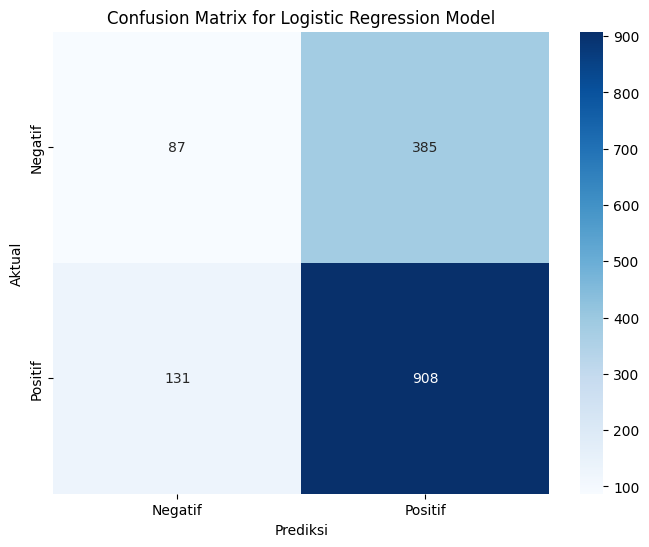

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

# Make predictions
val_preds_log_reg = log_reg_model.predict(X_val)
val_probs_log_reg = log_reg_model.predict_proba(X_val)[:, 1]  # Get probabilities for the positive class

# Calculate metrics
accuracy_log_reg = accuracy_score(y_val, val_preds_log_reg)
precision_log_reg = precision_score(y_val, val_preds_log_reg)
recall_log_reg = recall_score(y_val, val_preds_log_reg)
f1_log_reg = f1_score(y_val, val_preds_log_reg)
auc_score_log_reg = roc_auc_score(y_val, val_probs_log_reg)

# Print the results
print("Logistic Regression Model Metrics:")
print("Accuracy:", accuracy_log_reg)
print("Precision:", precision_log_reg)
print("Recall:", recall_log_reg)
print("F1 Score:", f1_log_reg)
print("AUC Score:", auc_score_log_reg)

# Calculate confusion matrix
cm_log_reg = confusion_matrix(y_val, val_preds_log_reg)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


## 6. Results and Summary

###Perbandingan Setiap Model


Training Random Forest...

Training XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:54:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Training Gradient Boosting...

Training Logistic Regression...

===== Model Comparison =====
                 Model  Accuracy  Precision    Recall        F1   AUC-ROC
2    Gradient Boosting  0.667770   0.701124  0.900866  0.788543  0.727065
1              XGBoost  0.667108   0.738011  0.799808  0.767667  0.726648
0        Random Forest  0.657842   0.729350  0.798845  0.762517  0.714552
3  Logistic Regression  0.662475   0.704247  0.877767  0.781491  0.705133


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Figure size 1200x600 with 0 Axes>

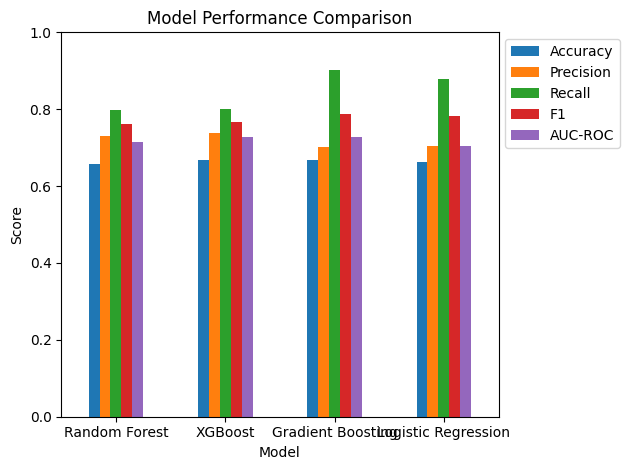

In [88]:
# ---- Model Comparison ----
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    # Predictions
    val_preds = model.predict(X_val)
    val_probs = model.predict_proba(X_val)[:, 1]

    # Calculate metrics
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_val, val_preds),
        'Precision': precision_score(y_val, val_preds),
        'Recall': recall_score(y_val, val_preds),
        'F1': f1_score(y_val, val_preds),
        'AUC-ROC': roc_auc_score(y_val, val_probs)
    }

    results.append(metrics)

    # ---- Results Comparison ----
results_df = pd.DataFrame(results)
print("\n===== Model Comparison =====")
print(results_df.sort_values('AUC-ROC', ascending=False))
# Visualize results
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
results_df.set_index('Model')[metrics_to_plot].plot(kind='bar', rot=0)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

###Submission

In [89]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Model Dictionary
models = {
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# Train and evaluate models
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)  # Train on the training set

    # Validation predictions
    val_preds = model.predict(X_val)  # Predict on the validation set
    val_probs = model.predict_proba(X_val)[:, 1]  # Get predicted probabilities for AUC-ROC

    # Calculate metrics
    print(f"\n{name} Validation Metrics:")
    print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f}")
    print(f"Precision: {precision_score(y_val, val_preds):.4f}")
    print(f"Recall: {recall_score(y_val, val_preds):.4f}")
    print(f"F1 Score: {f1_score(y_val, val_preds):.4f}")
    print(f"AUC-ROC: {roc_auc_score(y_val, val_probs):.4f}")
test_ids = df_test['id']
# Create submission files
for name, model in models.items():
    test_preds = model.predict(X_test)  # Predict on the test set
    submission = pd.DataFrame({
        'id': test_ids,  # Assuming test_ids is defined
        'pengiriman_tepat_waktu': test_preds
    })
    submission_file = f'submission_{name.lower().replace(" ", "_")}.csv'
    submission.to_csv(submission_file, index=False)
    print(f"\nSubmission file created for {name}: {submission_file}")



Training XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:57:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Validation Metrics:
Accuracy: 0.6671
Precision: 0.7380
Recall: 0.7998
F1 Score: 0.7677
AUC-ROC: 0.7266

Training Gradient Boosting...

Gradient Boosting Validation Metrics:
Accuracy: 0.6678
Precision: 0.7011
Recall: 0.9009
F1 Score: 0.7885
AUC-ROC: 0.7271

Training Logistic Regression...

Logistic Regression Validation Metrics:
Accuracy: 0.6625
Precision: 0.7042
Recall: 0.8778
F1 Score: 0.7815
AUC-ROC: 0.7051

Submission file created for XGBoost: submission_xgboost.csv

Submission file created for Gradient Boosting: submission_gradient_boosting.csv

Submission file created for Logistic Regression: submission_logistic_regression.csv


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
from google.colab import files

# Simpan DataFrame yang sudah dibersihkan ke file CSV
df_train.to_csv('cleaned_train.csv', index=False)

# Download file
files.download('cleaned_train.csv')

# Simpan DataFrame yang sudah dibersihkan ke file CSV
df_test.to_csv('cleaned_test.csv', index=False)

# Download file
files.download('cleaned_test.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>